In [4]:
import pandas as pd

# Read and Merge All the Data

In [16]:
all = pd.read_csv('df.csv', low_memory = False)
cahoots = pd.read_csv('cahoots.csv', low_memory = False)
other = pd.read_csv('other.csv', low_memory = False)

# Analysis of All

In [162]:
all.groupby('is_holiday')['secs_to_arrv'].describe()

,count,mean,std,min,25%,50%,75%,max
is_holiday,,,,,,,,
0,924820.0,2812.776958,7459.643093,0.0,0.0,578.0,2240.00,864041.0
1,28304.0,2485.160861,6024.469358,0.0,0.0,599.0,2138.25,150004.0


In [22]:
# Create binary flag for CAHOOTS
all['is_cahoots'] = all['primeunit'] == 'CAHOOT'

# Calculate % CAHOOTS per holiday status
share = all.groupby('is_holiday')['is_cahoots'].mean().reset_index()
share['is_holiday'] = share['is_holiday'].map({0: 'Non-Holiday', 1: 'Holiday'})
share.columns = ['Day Type', 'Proportion of Calls Handled by CAHOOTS']
print(share)

      Day Type  Proportion of Calls Handled by CAHOOTS
0  Non-Holiday                                0.148084
1      Holiday                                0.162239


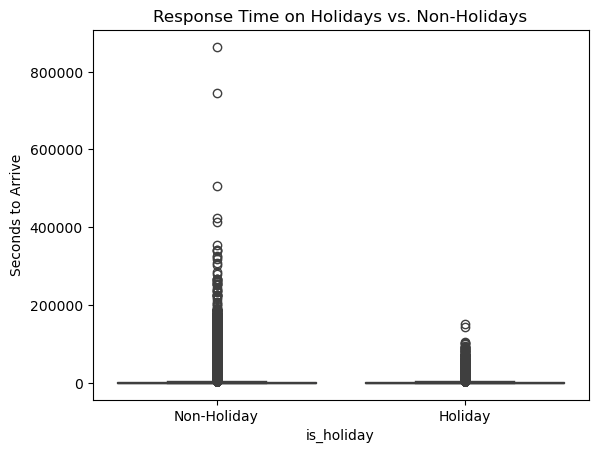

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='is_holiday', y='secs_to_arrv', data=all)
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
plt.ylabel('Seconds to Arrive')
plt.title('Response Time on Holidays vs. Non-Holidays')
plt.show()

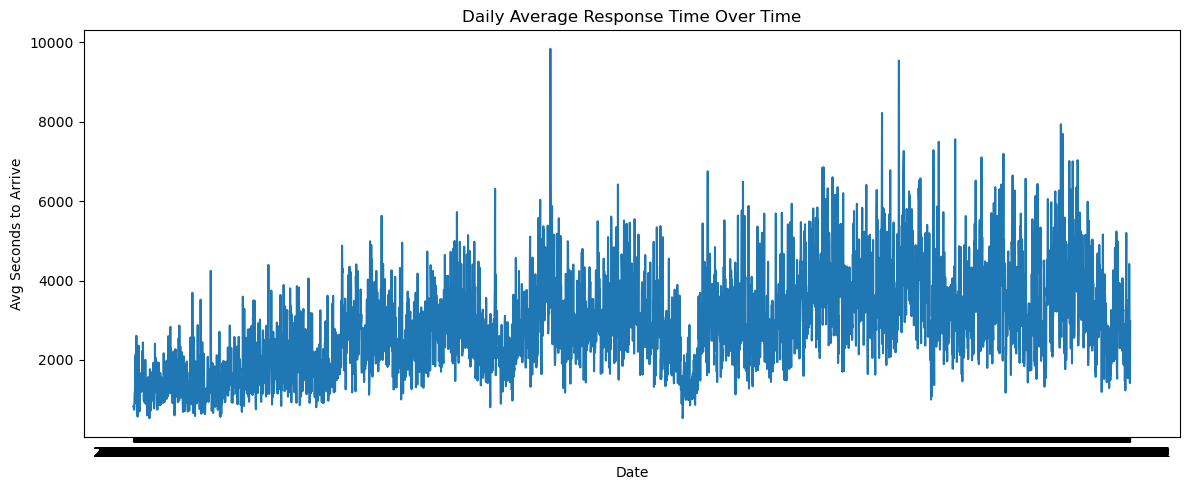

In [164]:
daily = all.groupby('date_only')['secs_to_arrv'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(daily['date_only'], daily['secs_to_arrv'])
plt.title('Daily Average Response Time Over Time')
plt.xlabel('Date')
plt.ylabel('Avg Seconds to Arrive')
plt.tight_layout()
plt.show()

# Initial T-test

In [218]:
from scipy.stats import ttest_ind

# Optionally drop NaNs or negative response times if not already done
holiday_times = cahoots[cahoots['is_holiday'] == 1]['secs_to_arrv'].dropna()
nonholiday_times = cahoots[cahoots['is_holiday'] == 0]['secs_to_arrv'].dropna()

# T-test: unequal variance (Welch’s t-test is safer for unequal sample sizes)
t_stat, p_val = ttest_ind(holiday_times, nonholiday_times, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.5f}")

if p_val < 0.05:
    print("Result: Statistically significant difference in response times.")
else:
    print("Result: No statistically significant difference.")

T-statistic: -4.969
P-value: 0.00000
Result: Statistically significant difference in response times.


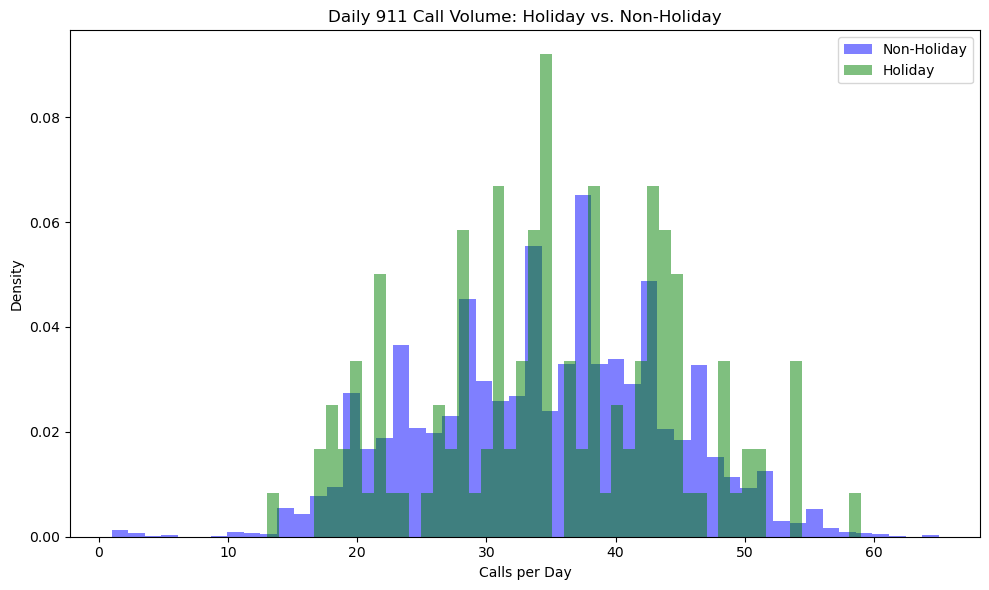

In [220]:
# Group by day and count calls
daily_counts = cahoots.groupby(['date_only', 'is_holiday']).size().reset_index(name='call_volume')
holiday_volumes = daily_counts[daily_counts['is_holiday'] == 1]['call_volume']
nonholiday_volumes = daily_counts[daily_counts['is_holiday'] == 0]['call_volume']
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(nonholiday_volumes, bins=50, alpha=0.5, density=True, label='Non-Holiday', color='blue')
plt.hist(holiday_volumes, bins=50, alpha=0.5, density=True, label='Holiday', color='green')

plt.xlabel('Calls per Day')
plt.ylabel('Density')
plt.title('Daily 911 Call Volume: Holiday vs. Non-Holiday')
plt.legend()
plt.tight_layout()
plt.show()

## Smooth and Normalize graph from above

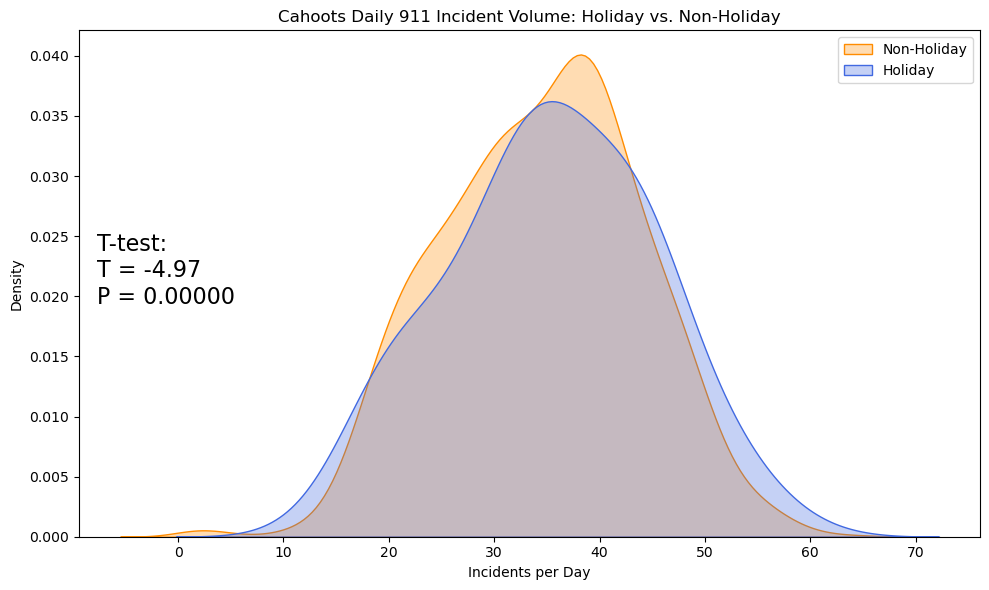

In [222]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# KDE plot
sns.kdeplot(nonholiday_volumes, label='Non-Holiday', fill=True, color='darkorange', alpha=0.3, bw_adjust=1.2)
sns.kdeplot(holiday_volumes, label='Holiday', fill=True, color='royalblue', alpha=0.3, bw_adjust=1.2)

plt.text(0.02, 0.60,
         f"T-test:\nT = {t_stat:.2f}\nP = {p_val:.5f}",
         transform=plt.gca().transAxes,
         fontsize=16, color='black', va='top')
plt.xlabel('Incidents per Day')
plt.ylabel('Density')
plt.title('Cahoots Daily 911 Incident Volume: Holiday vs. Non-Holiday')
plt.legend()
plt.tight_layout()
plt.show()

## Incidents per day by each holiday

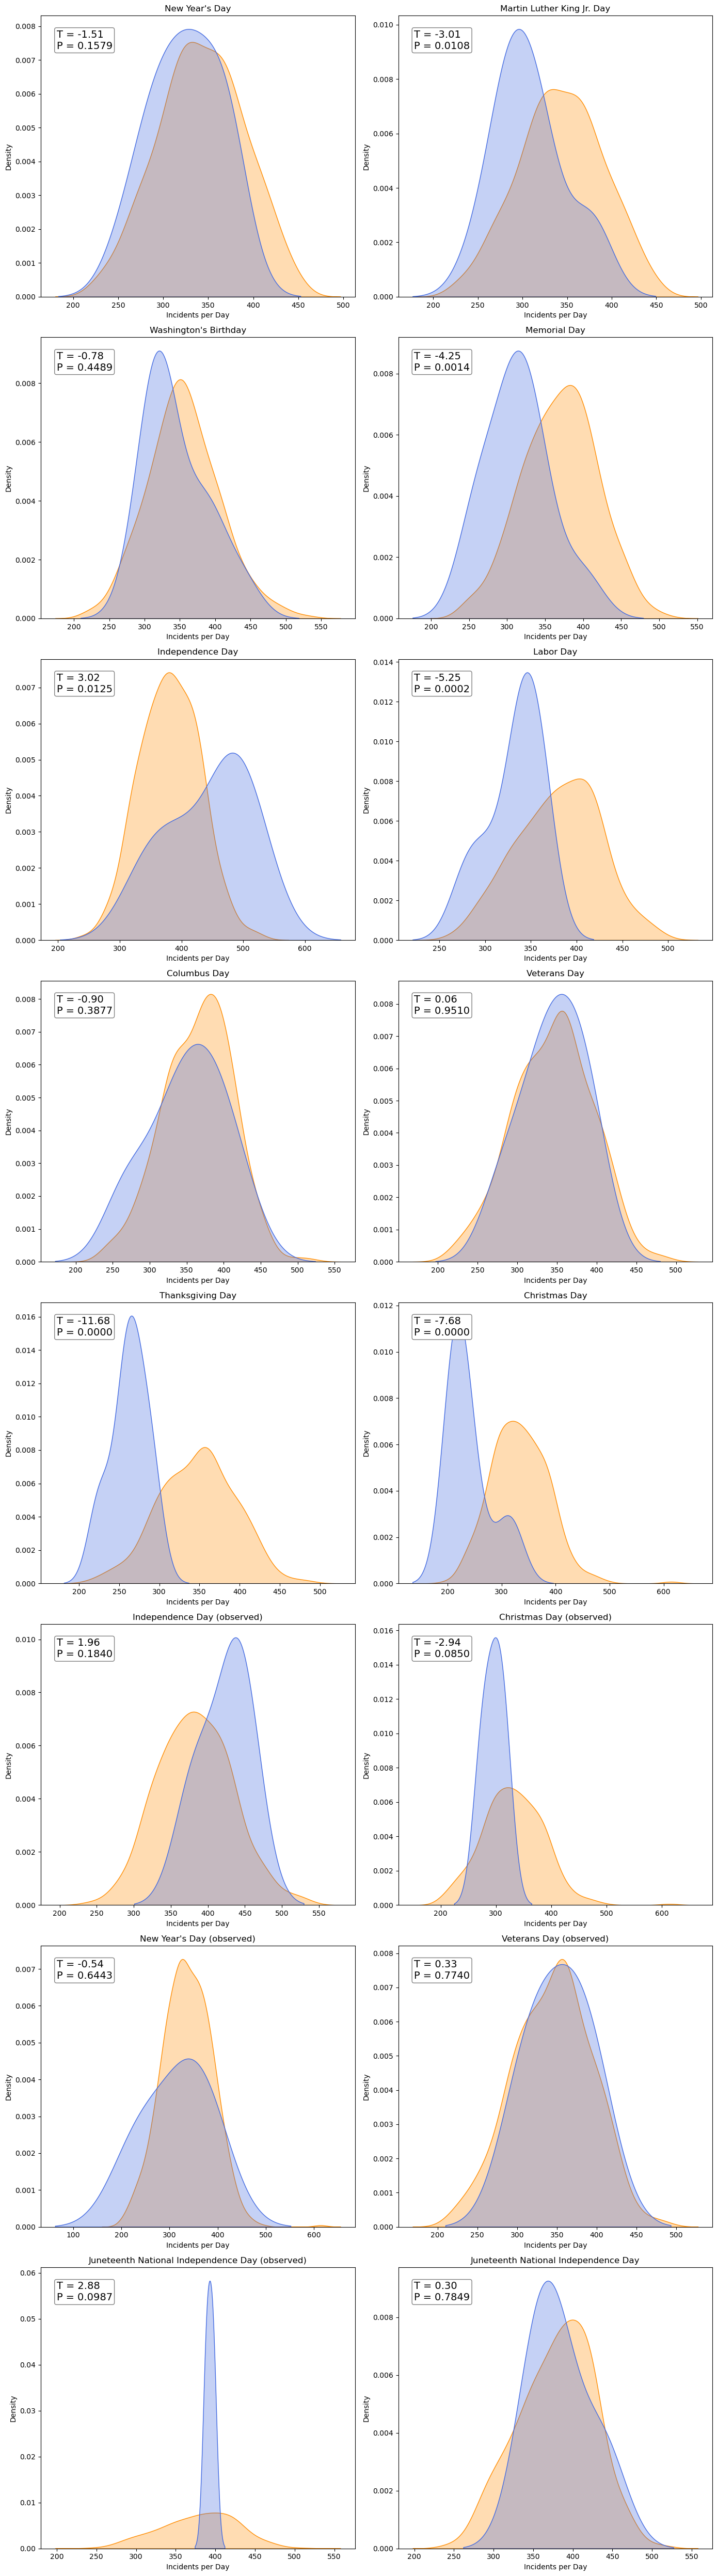

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Define main holidays to compare
main_holidays = ["New Year's Day", 'Martin Luther King Jr. Day',
       "Washington's Birthday", 'Memorial Day', 'Independence Day',
       'Labor Day', 'Columbus Day', 'Veterans Day', 'Thanksgiving Day',
       'Christmas Day', 'Independence Day (observed)',
       'Christmas Day (observed)', "New Year's Day (observed)",
       'Veterans Day (observed)',
       'Juneteenth National Independence Day (observed)',
       'Juneteenth National Independence Day']

# Prepare subplot grid
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(14, 50))
axes = axes.flatten()
all['date_only'] = pd.to_datetime(all['date_only'])
# Loop through holidays
for i, holiday in enumerate(main_holidays):
    ax = axes[i]

    # Identify the holiday's call dates
    holiday_days = df_all[df_all['holiday_name'] == holiday]['date_only'].unique()

    # Daily call volumes for the holiday
    holiday_volumes = df_all[df_all['date_only'].isin(holiday_days)].groupby('date_only').size()

    # For comparison: non-holiday days from the same month(s)
    holiday_months = pd.to_datetime(holiday_days).month
    nonholiday_days = df_all[
        df_all['date_only'].dt.month.isin(holiday_months) &
        (~df_all['date_only'].isin(holiday_days))
    ]
    nonholiday_volumes = nonholiday_days.groupby('date_only').size()

    # KDE plots
    if not nonholiday_volumes.empty:
        sns.kdeplot(nonholiday_volumes, label='Non-Holiday', fill=True, color='darkorange', alpha=0.3, ax=ax)
    if not holiday_volumes.empty:
        sns.kdeplot(holiday_volumes, label='Holiday', fill=True, color='royalblue', alpha=0.3, ax=ax)

    # T-test
    if len(holiday_volumes) > 1 and len(nonholiday_volumes) > 1:
        t_stat, p_val = ttest_ind(holiday_volumes, nonholiday_volumes, equal_var=False)
    else:
        t_stat, p_val = float('nan'), float('nan')

    # Add stats annotation
    ax.set_title(f"{holiday}")
    ax.set_xlabel('Incidents per Day')
    ax.set_ylabel('Density')
    ax.text(0.05, 0.95, f"T = {t_stat:.2f}\nP = {p_val:.4f}",
            transform=ax.transAxes,
            fontsize=14,
            verticalalignment='top',
            bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))

# Layout
plt.tight_layout()
plt.show()

# Response Times

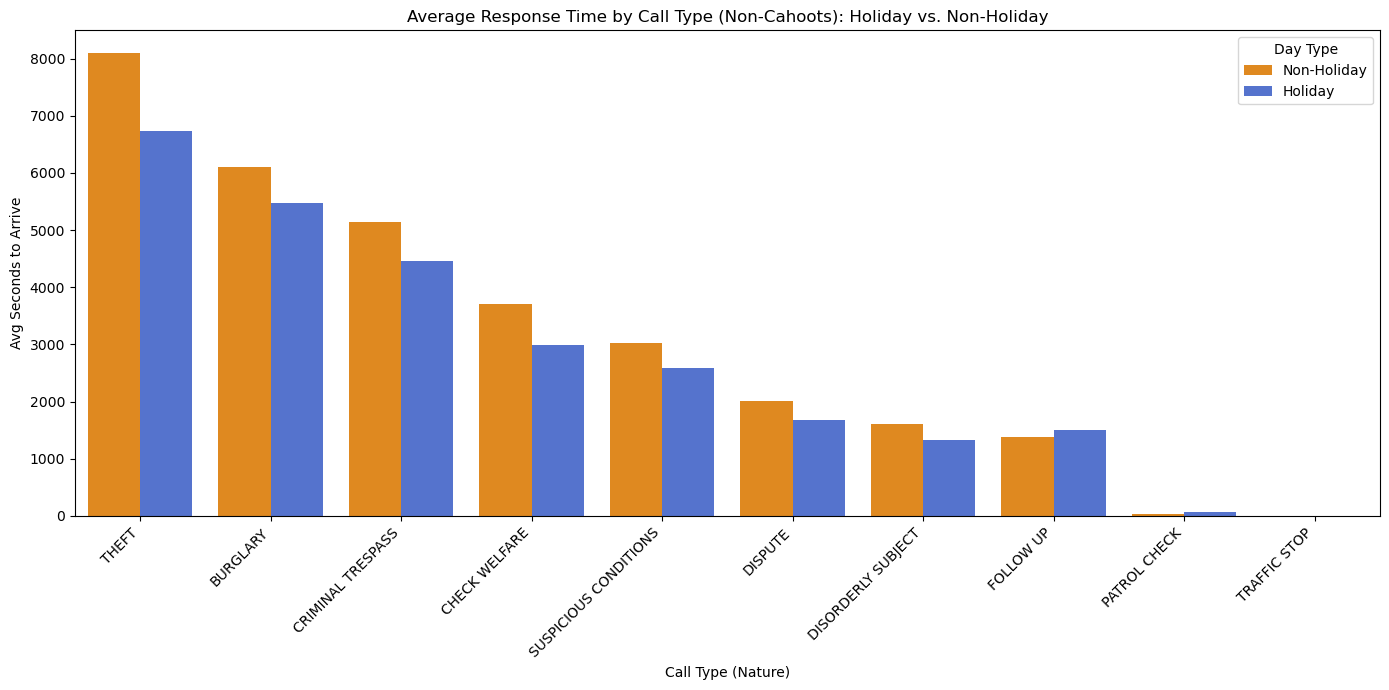

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter out zero/negative response times
df_rt = other[other['secs_to_arrv'] > 0].copy()

# Get top 10 'nature' types
top_natures = df_rt['nature'].value_counts().head(10).index.tolist()

# Filter only those top 10 types
df_top = df_rt[df_rt['nature'].isin(top_natures)]

# Group by call type and holiday status
grouped = df_top.groupby(['nature', 'is_holiday'])['secs_to_arrv'].mean().reset_index()

# Convert holiday flag to label
grouped['is_holiday'] = grouped['is_holiday'].map({0: 'Non-Holiday', 1: 'Holiday'})

# Sort by overall mean for visual consistency
order = df_top.groupby('nature')['secs_to_arrv'].mean().sort_values(ascending=False).index.tolist()

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(data=grouped, x='nature', y='secs_to_arrv', hue='is_holiday', order=order, palette=['darkorange', 'royalblue'])

plt.xticks(rotation=45, ha='right')
plt.xlabel('Call Type (Nature)')
plt.ylabel('Avg Seconds to Arrive')
plt.title('Average Response Time by Call Type (Non-Cahoots): Holiday vs. Non-Holiday')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

In [250]:
df_close = other[other['secs_to_close'] > 0].copy()
from scipy.stats import ttest_ind

holiday_close = df_close[df_close['is_holiday'] == 1]['secs_to_close']
nonholiday_close = df_close[df_close['is_holiday'] == 0]['secs_to_close']

t_stat, p_val = ttest_ind(holiday_close, nonholiday_close, equal_var=False)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_val:.5f}")
if p_val < 0.05:
    print("✅ Statistically significant difference in how long calls take to close.")
else:
    print("❌ No statistically significant difference.")

T-statistic: -9.27
P-value: 0.00000
✅ Statistically significant difference in how long calls take to close.


# Close Times

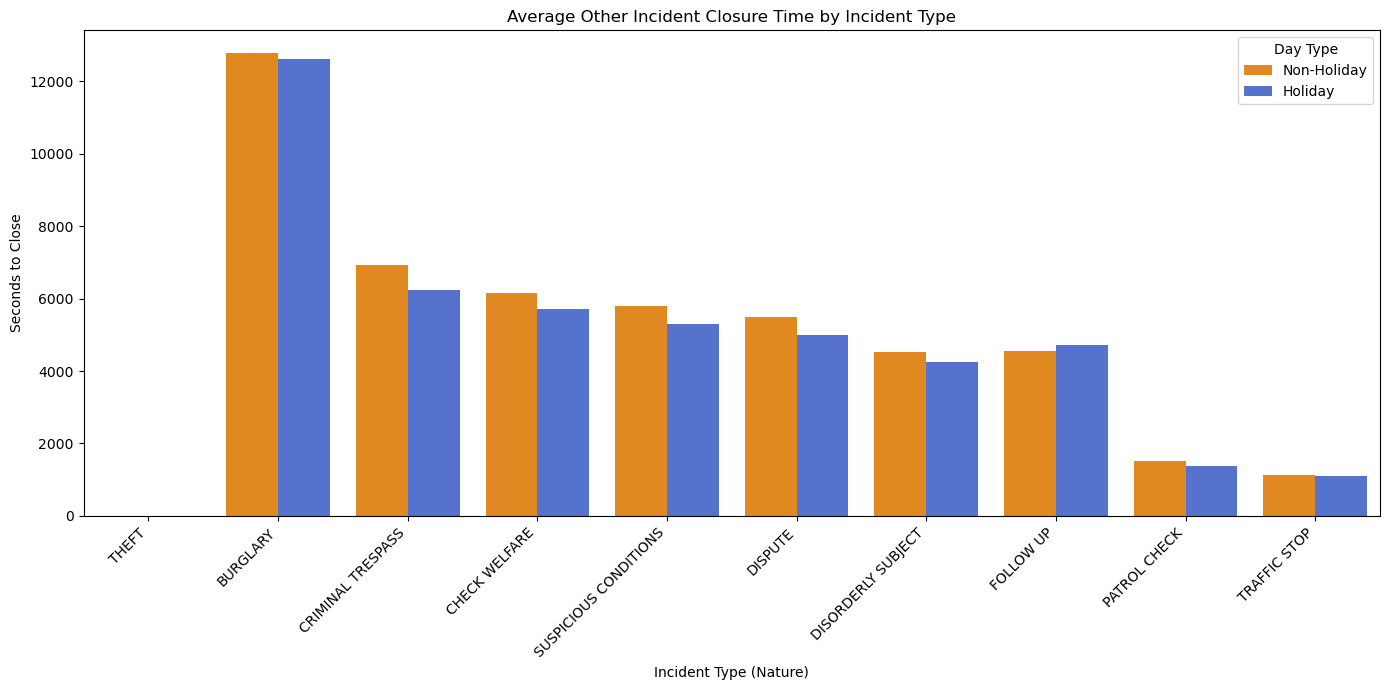

In [254]:
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

# Filter top 10 incident types
top_natures = df_close['nature'].value_counts().head(10).index.tolist()
df_top = df_close[df_close['nature'].isin(top_natures)]

# Group by call type and holiday status
avg_close_by_nature = df_top.groupby(['nature', 'is_holiday'])['secs_to_close'].mean().reset_index()
avg_close_by_nature['is_holiday'] = avg_close_by_nature['is_holiday'].map({0: 'Non-Holiday', 1: 'Holiday'})

# Sort call types by overall average close time
nature_order = df_top.groupby('nature')['secs_to_close'].mean().sort_values(ascending=False).index.tolist()

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(data=avg_close_by_nature, x='nature', y='secs_to_close', hue='is_holiday',
            order=order, palette=['darkorange', 'royalblue'])

plt.title("Average Other Incident Closure Time by Incident Type")
plt.xlabel("Incident Type (Nature)")
plt.ylabel("Seconds to Close")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Day Type")
plt.tight_layout()
plt.show()

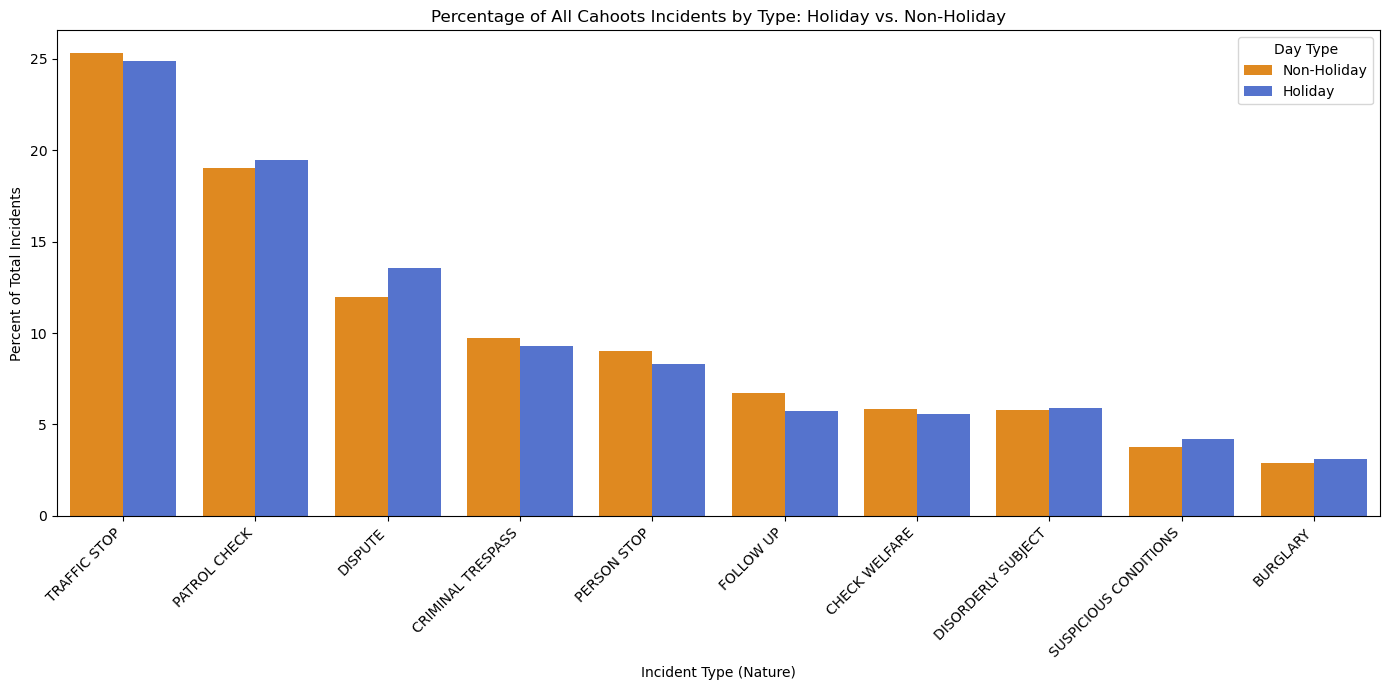

In [258]:
# Top 10 call types
top_natures = other['nature'].value_counts().head(10).index.tolist()
df_top = other[other['nature'].isin(top_natures)]

# Count total calls by holiday type (for denominator)
total_by_daytype = df_top.groupby('is_holiday').size()

# Count calls per type per holiday type
call_counts = df_top.groupby(['nature', 'is_holiday']).size().reset_index(name='count')

# Convert to percentage of total for each day type
call_counts['percent'] = call_counts.apply(
    lambda row: (row['count'] / total_by_daytype[row['is_holiday']]) * 100,
    axis=1
)

# Convert labels
call_counts['is_holiday'] = call_counts['is_holiday'].map({0: 'Non-Holiday', 1: 'Holiday'})

# Sort by non-holiday volume (to order x-axis consistently)
order = df_top[df_top['is_holiday'] == 0]['nature'].value_counts().loc[top_natures].index.tolist()

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(data=call_counts, x='nature', y='percent', hue='is_holiday',
            order=order, palette=['darkorange', 'royalblue'])

plt.title("Percentage of All Cahoots Incidents by Type: Holiday vs. Non-Holiday")
plt.xlabel("Incident Type (Nature)")
plt.ylabel("Percent of Total Incidents")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

In [260]:
# Calculate % difference
pivot = call_counts.pivot(index='nature', columns='is_holiday', values='percent')
pivot['delta'] = pivot['Holiday'] - pivot['Non-Holiday']
pivot.sort_values(by='delta', ascending=False)

is_holiday,Holiday,Non-Holiday,delta
nature,,,
DISPUTE,13.527561,11.979141,1.548420
PATROL CHECK,19.436466,18.999022,0.437443
SUSPICIOUS CONDITIONS,4.212830,3.784323,0.428507
BURGLARY,3.098071,2.872973,0.225098
DISORDERLY SUBJECT,5.922582,5.799316,0.123267
CHECK WELFARE,5.587471,5.821111,-0.233640
TRAFFIC STOP,24.846122,25.282327,-0.436205
CRIMINAL TRESPASS,9.294214,9.739672,-0.445458
PERSON STOP,8.323075,9.023059,-0.699984


In [264]:
from scipy.stats import chi2_contingency
import pandas as pd

# Filter for top 10 incident types
top_natures = other['nature'].value_counts().head(10).index.tolist()
df_top = other[other['nature'].isin(top_natures)]

# Group counts
count_table = pd.crosstab(df_top['nature'], df_top['is_holiday'])

# Add column labels
count_table.columns = ['Non-Holiday', 'Holiday']

# Calculate % difference and total count difference
count_table['total_diff'] = count_table['Holiday'] - count_table['Non-Holiday']
count_table['percent_holiday'] = count_table['Holiday'] / (count_table['Holiday'] + count_table['Non-Holiday']) * 100
count_table['percent_nonholiday'] = count_table['Non-Holiday'] / (count_table['Holiday'] + count_table['Non-Holiday']) * 100
count_table['percent_diff'] = count_table['percent_holiday'] - count_table['percent_nonholiday']

# Chi-squared test across entire table
chi2, p, dof, expected = chi2_contingency(count_table.iloc[:, :2])

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p:.5f}")

# Sort and view
count_table_sorted = count_table.sort_values(by='percent_diff', ascending=False)
count_table_sorted

Chi-square statistic: 71.61
P-value: 0.00000


,Non-Holiday,Holiday,total_diff,percent_holiday,percent_nonholiday,percent_diff
nature,,,,,,
DISPUTE,58808,1978,-56830,3.254039,96.745961,-93.491922
SUSPICIOUS CONDITIONS,18578,616,-17962,3.209336,96.790664,-93.581327
BURGLARY,14104,453,-13651,3.111905,96.888095,-93.776190
PATROL CHECK,93270,2842,-90428,2.956967,97.043033,-94.086066
DISORDERLY SUBJECT,28470,866,-27604,2.952004,97.047996,-94.095991
TRAFFIC STOP,124116,3633,-120483,2.843858,97.156142,-94.312284
CHECK WELFARE,28577,817,-27760,2.779479,97.220521,-94.441042
CRIMINAL TRESPASS,47814,1359,-46455,2.763712,97.236288,-94.472576
PERSON STOP,44296,1217,-43079,2.673961,97.326039,-94.652077


In [24]:
from scipy.stats import ttest_ind
import pandas as pd

# Filter valid response times
df_rt = cahoots[cahoots['secs_to_arrv'] > 0].copy()

# Top incident types to include
top_natures = df_rt['nature'].value_counts().head(10).index.tolist()

# Store results
response_results = []

for nature in top_natures:
    sub = df_rt[df_rt['nature'] == nature]
    holiday = sub[sub['is_holiday'] == 1]['secs_to_arrv']
    nonholiday = sub[sub['is_holiday'] == 0]['secs_to_arrv']

    if len(holiday) > 1 and len(nonholiday) > 1:
        t_stat, p_val = ttest_ind(holiday, nonholiday, equal_var=False)
        delta = holiday.mean() - nonholiday.mean()
    else:
        t_stat, p_val, delta = float('nan'), float('nan'), float('nan')

    response_results.append({
        'nature': nature,
        'mean_holiday': holiday.mean(),
        'mean_nonholiday': nonholiday.mean(),
        'delta': delta,
        't_stat': t_stat,
        'p_val': p_val
    })

# Convert to DataFrame
response_df = pd.DataFrame(response_results).sort_values(by='delta', ascending=False)
response_df

,nature,mean_holiday,mean_nonholiday,delta,t_stat,p_val
5,SUICIDAL SUBJECT,2563.529070,2522.572673,40.956396,0.178931,8.581887e-01
1,CHECK WELFARE,5068.510544,5206.263118,-137.752574,-0.599594,5.489185e-01
8,INTOXICATED SUBJECT,3341.319444,3559.962281,-218.642836,-0.432905,6.663188e-01
6,"SUICIDAL SUBJECT, CAHOOTS",2807.581967,3450.725304,-643.143337,-2.433233,1.616704e-02
4,"CHECK WELFARE, CAHOOTS",5131.377261,5818.953940,-687.576679,-1.629772,1.039075e-01
0,ASSIST PUBLIC- POLICE,6480.074951,7267.967950,-787.893000,-3.269366,1.111101e-03
2,TRANSPORT,5368.727642,6165.720082,-796.992440,-3.676462,2.520449e-04
3,"PUBLIC ASSIST, CAHOOTS",7744.611588,8569.742215,-825.130627,-1.820558,6.926716e-02
9,"ASSIST PD, CAHOOTS",1254.019231,2779.239975,-1525.220744,-5.873642,7.961741e-08
7,"TRANSPORT, CAHOOTS",5606.192593,7568.415493,-1962.222900,-3.507989,5.928692e-04


In [272]:
# Filter valid close times
df_close = other[other['secs_to_close'] > 0].copy()

# Top types (reuse same top_natures if you want consistency)
close_results = []

for nature in top_natures:
    sub = df_close[df_close['nature'] == nature]
    holiday = sub[sub['is_holiday'] == 1]['secs_to_close']
    nonholiday = sub[sub['is_holiday'] == 0]['secs_to_close']

    if len(holiday) > 1 and len(nonholiday) > 1:
        t_stat, p_val = ttest_ind(holiday, nonholiday, equal_var=False)
        delta = holiday.mean() - nonholiday.mean()
    else:
        t_stat, p_val, delta = float('nan'), float('nan'), float('nan')

    close_results.append({
        'nature': nature,
        'mean_holiday': holiday.mean(),
        'mean_nonholiday': nonholiday.mean(),
        'delta': delta,
        't_stat': t_stat,
        'p_val': p_val
    })

# Convert to DataFrame
close_df = pd.DataFrame(close_results).sort_values(by='delta', ascending=False)
close_df

,nature,mean_holiday,mean_nonholiday,delta,t_stat,p_val
5,FOLLOW UP,4713.155767,4545.691519,167.464247,0.693765,0.488009
6,TRAFFIC STOP,1101.371043,1134.288284,-32.917240,-0.758857,0.447984
4,PATROL CHECK,1380.738472,1528.644067,-147.905595,-2.333503,0.019673
8,BURGLARY,12615.209713,12764.845368,-149.635655,-0.265195,0.790974
3,DISORDERLY SUBJECT,4252.715935,4518.152076,-265.436141,-1.657526,0.097747
2,CHECK WELFARE,5704.236230,6139.796528,-435.560298,-1.039650,0.298801
7,SUSPICIOUS CONDITIONS,5298.175325,5784.722201,-486.546877,-1.573746,0.116015
0,DISPUTE,4995.639353,5498.015053,-502.375700,-3.931847,0.000087
1,CRIMINAL TRESPASS,6233.805740,6920.661723,-686.855983,-3.209881,0.001356
9,THEFT,11469.081505,12898.489580,-1429.408075,-1.965783,0.050135


In [180]:
from scipy.stats import ttest_ind

# Get the top 10 call types again
top_natures = df_rt['nature'].value_counts().head(10).index.tolist()

# Store results
results = []

# Loop through each call type
for nature in top_natures:
    sub = df_rt[df_rt['nature'] == nature]
    h_times = sub[sub['is_holiday'] == 1]['secs_to_arrv']
    nh_times = sub[sub['is_holiday'] == 0]['secs_to_arrv']

    if len(h_times) > 1 and len(nh_times) > 1:
        t_stat, p_val = ttest_ind(h_times, nh_times, equal_var=False)
    else:
        t_stat, p_val = float('nan'), float('nan')

    results.append({'nature': nature, 't_stat': t_stat, 'p_value': p_val})

# Create DataFrame of results
ttest_df = pd.DataFrame(results).sort_values(by='p_value')
ttest_df

,nature,t_stat,p_value
4,DISORDERLY SUBJECT,-4.876113,0.000001
0,DISPUTE,-4.009952,0.000063
8,TRAFFIC STOP,-3.998266,0.000066
5,TRANSPORT,-3.358563,0.000819
2,CRIMINAL TRESPASS,-3.335546,0.000873
3,ASSIST PUBLIC- POLICE,-2.654238,0.008051
1,CHECK WELFARE,-2.276819,0.022913
9,SUSPICIOUS CONDITIONS,-1.731891,0.083767
6,PATROL CHECK,1.212345,0.225900
7,FOLLOW UP,0.551787,0.581321
